In [ ]:
!pip install imbalanced-learn
!pip install gxboost
!pip install plotly
!pip install -U kaleido==0.2.1

ERROR: Could not find a version that satisfies the requirement gxboost (from versions: none)
ERROR: No matching distribution found for gxboost


In [ ]:

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#SMOTE
from imblearn.over_sampling import SMOTE
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

In [ ]:

# Caminho preenchido com o nome do arquivo correto
file_path = "WineQT.csv"

# Carregando a última versão do dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path,
)

print("First 5 records:\n", df.head())

/tmp/ipykernel_1943/3648731185.py:5: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
First 5 records:
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.

# Parte 1 — Compreensão do Problema

## 1.1 Contexto e objetivo

A indústria vitivinícola tem grande relevância econômica e cultural em diversos países. Tradicionalmente, a qualidade de um vinho é avaliada por especialistas por meio de análises sensoriais, que consideram aspectos como aroma, sabor, acidez e equilíbrio. Esse processo, embora valioso, é subjetivo, demanda tempo e depende da experiência do avaliador.

Com o avanço das técnicas de ciência de dados, tornou-se possível utilizar características físico-químicas medidas durante a produção — como acidez, teor alcoólico, densidade e níveis de dióxido de enxofre — para auxiliar na previsão da qualidade do produto. Modelos preditivos podem apoiar enólogos e produtores na tomada de decisão, permitindo ajustes no processo produtivo e contribuindo para a padronização da qualidade.

O objetivo deste projeto é desenvolver um modelo de classificação capaz de prever a qualidade de um vinho a partir de suas características físico-químicas, utilizando a base Wine Quality (vinho tinto).

## 1.2 Definição da variável-alvo

A variável-alvo é a qualidade do vinho. Na base original, ela é expressa por uma nota inteira atribuída por especialistas. Para simplificar o problema e torná-lo uma tarefa de classificação binária, a nota foi convertida em duas categorias:

- **Alta qualidade (1):** nota maior ou igual a 7;
- **Baixa/Média qualidade (0):** nota menor que 7.

A coluna original `quality` é utilizada apenas como base para a criação do alvo, e não como variável preditora — incluí-la entre as features entregaria a resposta ao modelo, comprometendo a validade da avaliação.

## 1.3 Transformação em classificação binária

A nova variável-alvo (`quality_class`) foi criada aplicando o critério definido acima sobre a coluna `quality`. Após a transformação, observou-se que as classes são desbalanceadas: apenas cerca de 13,9% das amostras pertencem à categoria de alta qualidade. Esse desbalanceamento será considerado nas etapas de modelagem e avaliação.

In [ ]:
df['quality_class'] = (df['quality'] >= 7).astype(int)

# Parte 2 — Análise Exploratória de Dados (EDA)

Nesta etapa, investigamos a estrutura e o comportamento das variáveis, com foco em compreender suas distribuições, relações e possíveis anomalias, antes da modelagem.

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_class
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379,0.139108
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116,0.346210
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000,0.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000,0.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000,1.000000


In [ ]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_class
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826,0.123212
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892,-0.304523
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011,0.251146
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344,0.064145
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099,-0.103985
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268,-0.055977
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389,-0.113373
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926,-0.148670
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904,-0.073318
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954,0.208020


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  quality_class         1143 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 125.1 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=['Id']).duplicated().sum()


np.int64(125)

In [ ]:
df['quality'].value_counts().sort_index()

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


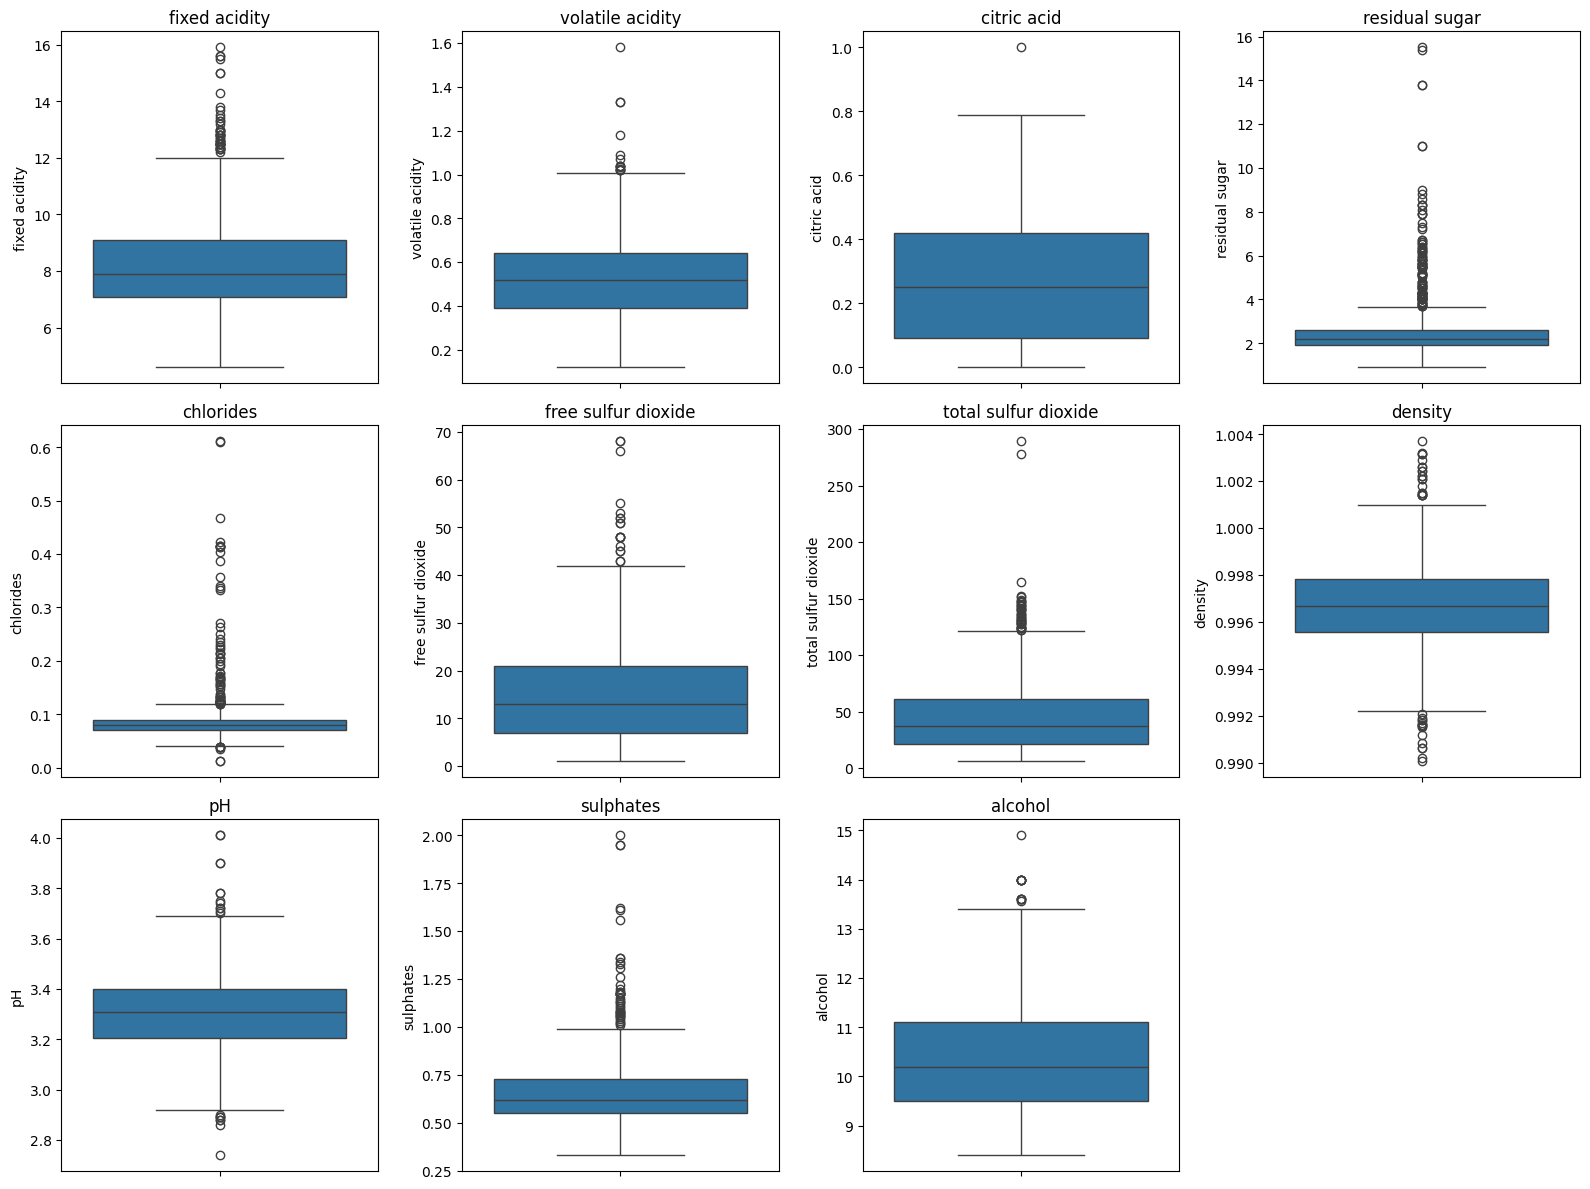

In [ ]:
colunas_num = df.columns.drop(['Id', 'quality', 'quality_class'])

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, coluna in enumerate(colunas_num):
    sns.boxplot(y=df[coluna], ax=axes[i])
    axes[i].set_title(coluna)

axes[11].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wine-quality-classification/results/boxplot.png', dpi=150, bbox_inches='tight')

plt.show()

In [ ]:
colunas_num = df.columns.drop(['Id', 'quality', 'quality_class'])

for coluna in colunas_num:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[coluna] < limite_inf) | (df[coluna] > limite_sup)).sum()
    print(f"{coluna}: {n_outliers} outliers")

fixed acidity: 44 outliers
volatile acidity: 14 outliers
citric acid: 1 outliers
residual sugar: 110 outliers
chlorides: 77 outliers
free sulfur dioxide: 18 outliers
total sulfur dioxide: 40 outliers
density: 36 outliers
pH: 20 outliers
sulphates: 43 outliers
alcohol: 12 outliers


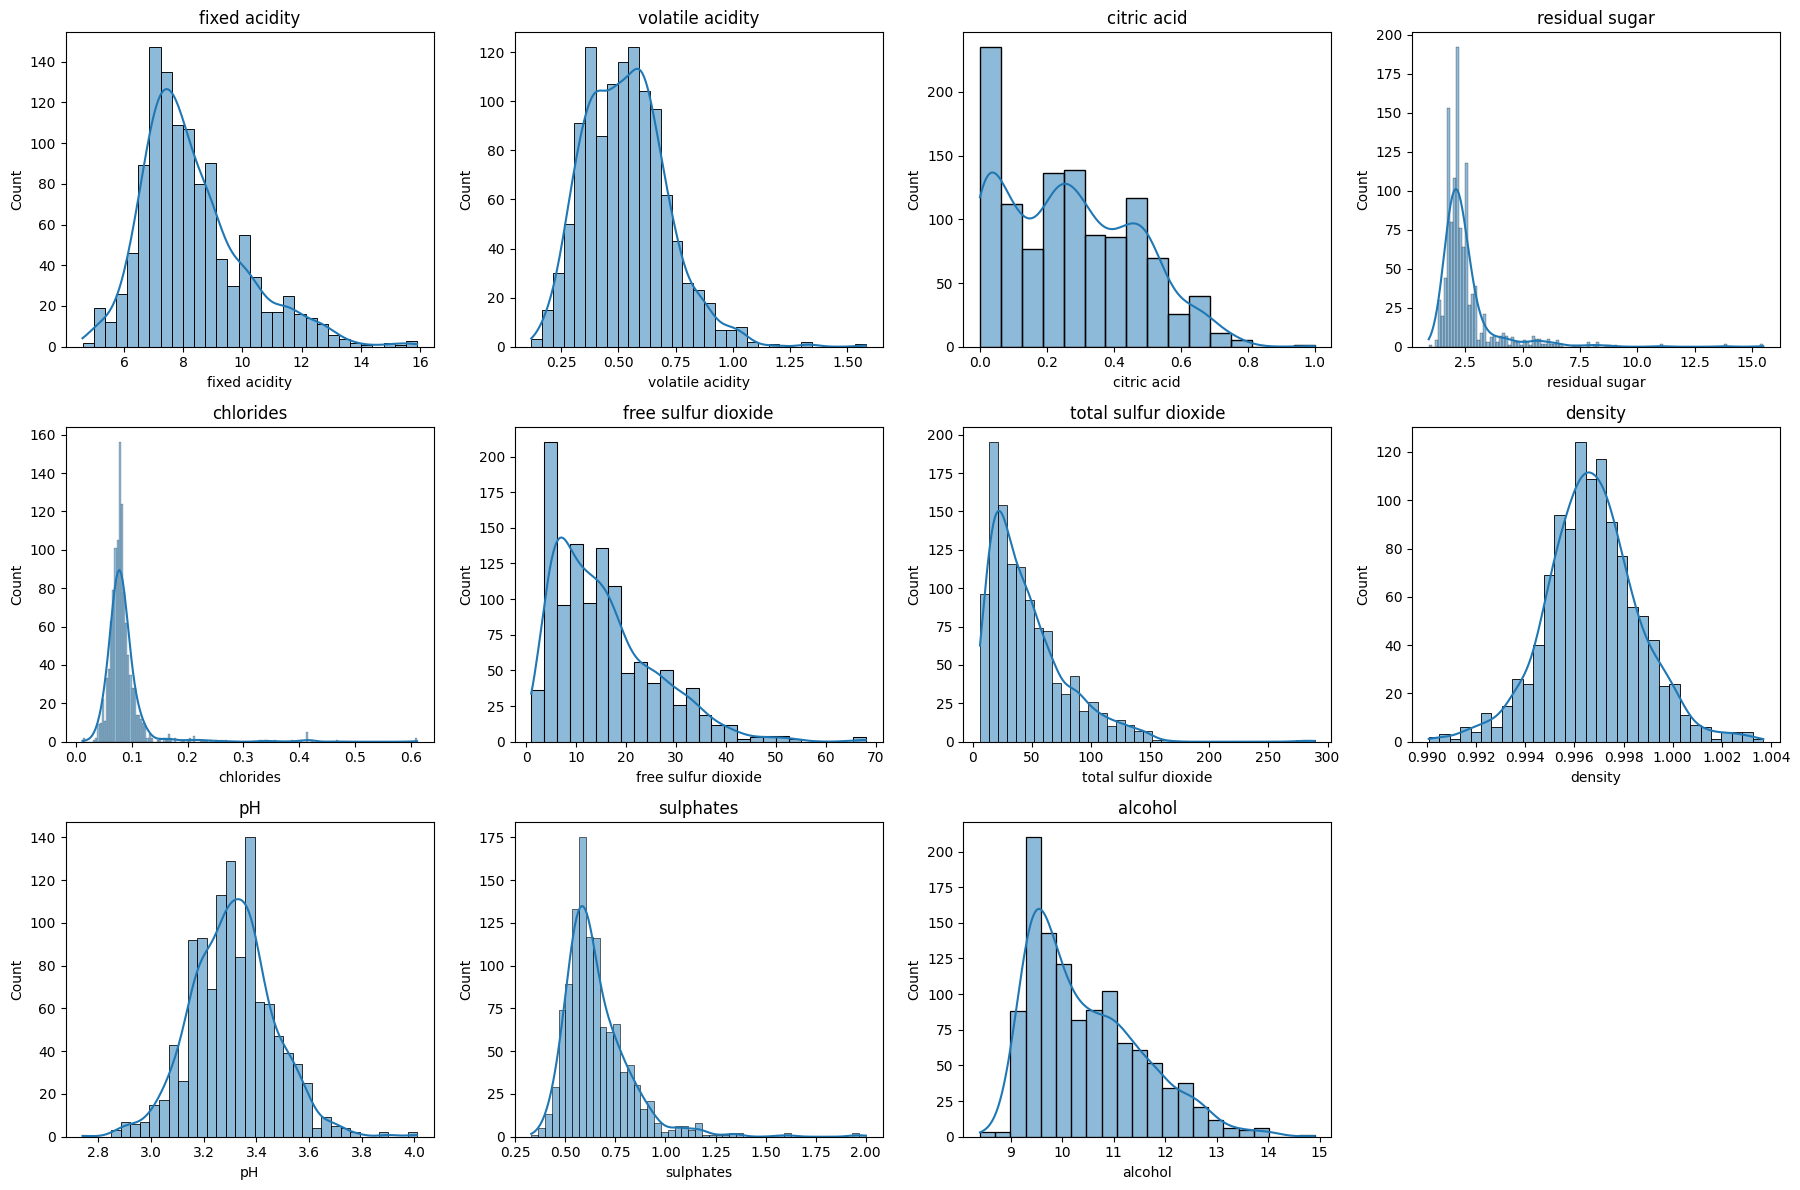

In [ ]:
colunas_num = df.columns.drop(['quality', 'Id'])
fig, axes = plt.subplots(3,4, figsize=(18,12))
axes = axes.flatten()
for i, coluna in enumerate(colunas_num):
    sns.histplot(df[coluna], ax=axes[i], kde=True)
    axes[i].set_title(coluna)
axes[11].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wine-quality-classification/results/histplot.png', dpi=150, bbox_inches='tight')
plt.show()

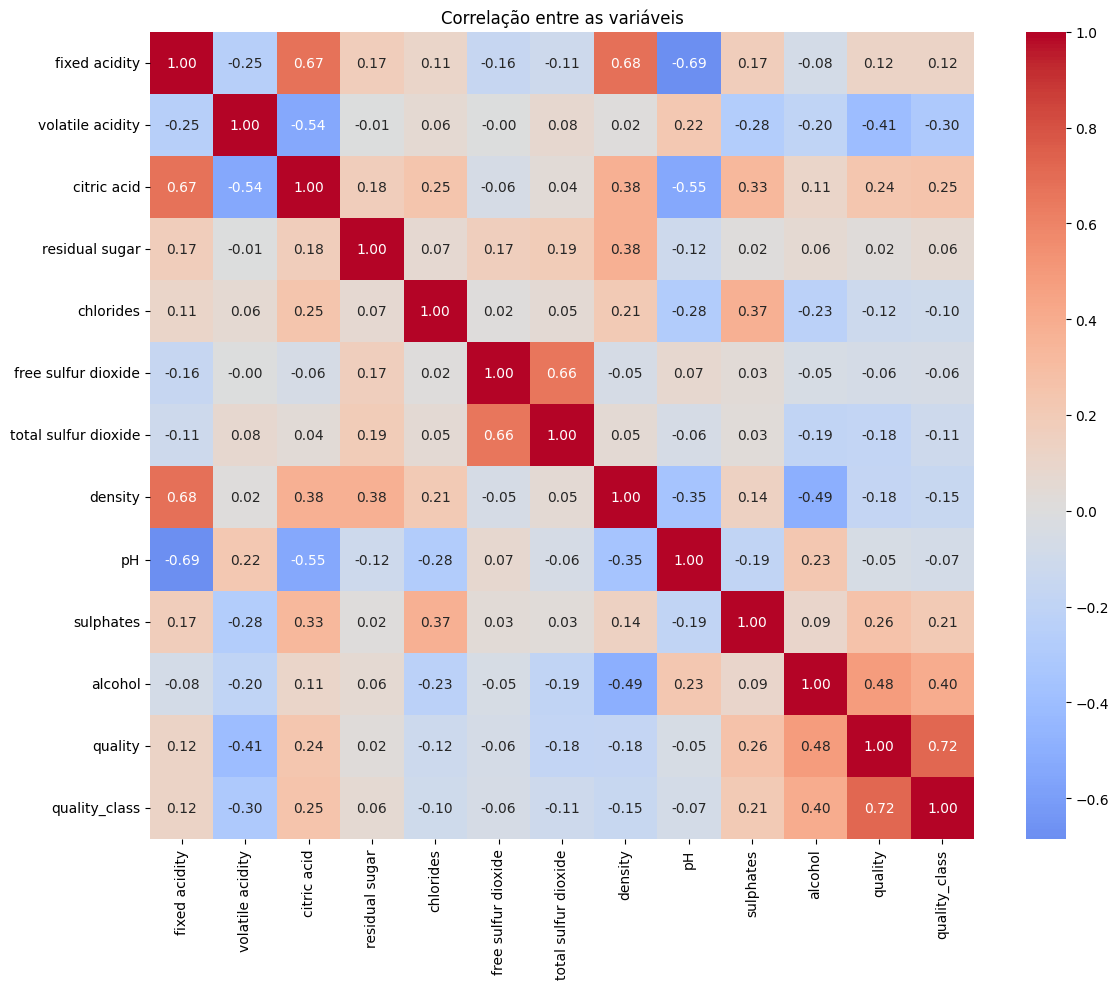

In [ ]:
corr = df.drop(columns=['Id']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlação entre as variáveis')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wine-quality-classification/results/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df.drop(columns=['Id']).corr()['quality'].sort_values(ascending=False)


,quality
quality,1.000000
quality_class,0.720433
alcohol,0.484866
sulphates,0.257710
citric acid,0.240821
fixed acidity,0.121970
residual sugar,0.022002
pH,-0.052453
free sulfur dioxide,-0.063260
chlorides,-0.124085


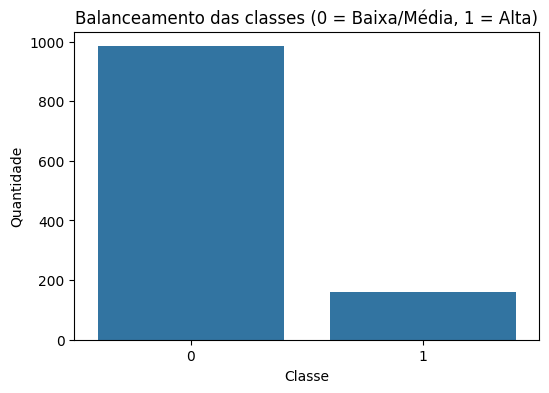

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='quality_class', data=df)
plt.title('Balanceamento das classes (0 = Baixa/Média, 1 = Alta)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.savefig('/content/drive/MyDrive/wine-quality-classification/results/countplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Síntese da Análise Exploratória

A base contém 1.143 amostras de vinho tinto, sem valores faltantes, com 11 variáveis físico-químicas e a nota de qualidade. Foram identificadas 125 amostras duplicadas (consideradas as variáveis físico-químicas, desconsiderando o identificador), que serão tratadas na etapa de pré-processamento.

A variável de qualidade foi transformada em uma classificação binária (alta qualidade para nota ≥ 7; baixa/média para nota < 7). As classes são fortemente desbalanceadas: apenas 13,9% das amostras são de alta qualidade.

A aplicação da regra do intervalo interquartil (IQR) identificou outliers em todas as variáveis, com destaque para o açúcar residual (110 ocorrências) e os cloretos (77), seguidos por acidez fixa (44), sulfatos (43) e dióxido de enxofre total (40). A inspeção das distribuições indica que esses valores decorrem majoritariamente da assimetria natural das variáveis (caudas à direita), e não de inconsistências de medição. Por representarem características físico-químicas plausíveis de vinhos reais — como exemplares mais doces (açúcar residual elevado) ou mais salinos (cloretos elevados) —, os outliers foram mantidos na base. Adicionalmente, os modelos baseados em árvore escolhidos para a modelagem são robustos à presença de valores extremos, o que reforça a decisão de não removê-los.

#Parte 3  Pré-processamento

In [ ]:
df = df.drop_duplicates(subset=df.columns.drop('Id'))
print(df.shape)

(1018, 14)


In [ ]:
#proporção de enxofre livre sobre o total
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']

# acidez total (fixa + volátil)
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity']

print(df['sulfur_ratio'].isnull().sum())
print((df['total sulfur dioxide'] == 0).sum())

0
0


In [ ]:
X = df.drop(columns=['Id', 'quality', 'quality_class'])
y = df['quality_class']


(1018, 13)
(1018,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X.columns.tolist())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


(814, 13)
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'sulfur_ratio', 'total_acidity']


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Conferir o efeito:
print("Antes do SMOTE:", y_train.value_counts().to_dict())
print("Depois do SMOTE:", y_train_smote.value_counts().to_dict())

Antes do SMOTE: {0: 704, 1: 110}
Depois do SMOTE: {0: 704, 1: 704}


# Parte 4 — Desenvolvimento dos Modelos


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Baseline
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)

# Random Forest + SMOTE
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [ ]:
from xgboost import XGBClassifier

# razão entre classes no treino: nº de negativos / nº de positivos
peso = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(peso, 2))

#XGBoost
xgb = XGBClassifier(scale_pos_weight=peso, random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

#XGBoost + SMOTE
xgb_smote = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

scale_pos_weight: 6.4


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# Parte 5 - Avaliação dos Modelos:

## Comparação final e escolha do modelo

Os seis modelos foram avaliados no conjunto de teste, priorizando o F1-score da
classe "Alta Qualidade" como critério principal, por equilibrar precision e recall
em um cenário de classes desbalanceadas.

O **XGBoost com SMOTE** apresentou o melhor desempenho geral (F1 = 0,656 e recall = 0,778),
sendo capaz de identificar 21 dos 27 vinhos de alta qualidade do conjunto de teste.
A aplicação do SMOTE foi determinante: tanto no Random Forest quanto no XGBoost, o
balanceamento por reamostragem elevou substancialmente o recall da classe minoritária,
sem comprometer a capacidade de separação (ROC-AUC entre 0,89 e 0,91).

Observa-se ainda que o ROC-AUC isoladamente não distingue bem os modelos (todos entre
0,886 e 0,919), reforçando a importância de avaliar precision, recall e F1 em problemas
desbalanceados. O modelo selecionado para a etapa de interpretação é o **XGBoost + SMOTE**.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def avaliar(nome, modelo, X_test_scaled, y_test):
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    print(f"===== {nome} =====")
    print(classification_report(y_test, y_pred, digits=3))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
    print("Matriz de confusão:")
    print(confusion_matrix(y_test, y_pred))
    print()

avaliar("Regressão Logística", log_reg, X_test_scaled, y_test)
avaliar("Random Forest", rf, X_test_scaled, y_test)
avaliar("Gradient Boosting", gb, X_test_scaled, y_test)
avaliar("XGBoost", xgb, X_test_scaled, y_test)
avaliar("Random Forest + SMOTE", rf_smote, X_test_scaled, y_test)
avaliar("XGBoost + SMOTE", xgb_smote, X_test_scaled, y_test)

===== Regressão Logística =====
              precision    recall  f1-score   support

           0      0.953     0.802     0.871       177
           1      0.364     0.741     0.488        27

    accuracy                          0.794       204
   macro avg      0.658     0.772     0.679       204
weighted avg      0.875     0.794     0.820       204

ROC-AUC: 0.886
Matriz de confusão:
[[142  35]
 [  7  20]]

===== Random Forest =====
              precision    recall  f1-score   support

           0      0.907     0.989     0.946       177
           1      0.818     0.333     0.474        27

    accuracy                          0.902       204
   macro avg      0.862     0.661     0.710       204
weighted avg      0.895     0.902     0.883       204

ROC-AUC: 0.919
Matriz de confusão:
[[175   2]
 [ 18   9]]

===== Gradient Boosting =====
              precision    recall  f1-score   support

           0      0.912     0.938     0.925       177
           1      0.500     0.4

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

def coletar_metricas(nome, modelo, X_test_scaled, y_test):
    """Extrai as métricas da classe positiva (1 = Alta Qualidade) e retorna um dict."""
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),       # classe 1 por padrão
        'Precision': precision_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

In [ ]:
modelos = {
    'Reg. Logística': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb,
    'RF + SMOTE': rf_smote,
    'XGBoost + SMOTE': xgb_smote
}

# aplica a função em cada modelo e junta tudo num DataFrame
resultados = pd.DataFrame([
    coletar_metricas(nome, modelo, X_test_scaled, y_test)
    for nome, modelo in modelos.items()
])

# ordena do melhor pro pior pelo F1
resultados = resultados.sort_values('F1', ascending=False).reset_index(drop=True)
resultados.index = resultados.index + 1

# arredonda pra ficar legível
resultados.round(3)

,Modelo,Acurácia,Recall,Precision,F1,ROC-AUC
1,XGBoost + SMOTE,0.892,0.778,0.568,0.656,0.896
2,RF + SMOTE,0.897,0.667,0.600,0.632,0.909
3,XGBoost,0.897,0.593,0.615,0.604,0.897
4,Reg. Logística,0.794,0.741,0.364,0.488,0.886
5,Random Forest,0.902,0.333,0.818,0.474,0.919
6,Gradient Boosting,0.868,0.407,0.500,0.449,0.893


In [ ]:

# transformar de formato largo pra longo (cada linha = um modelo + uma métrica)
df_long = resultados.melt(id_vars='Modelo',
                          value_vars=['Recall', 'F1', 'ROC-AUC'],
                          var_name='Métrica', value_name='Score')

fig = px.bar(df_long, x='Modelo', y='Score', color='Métrica',
             barmode='group', text='Score',
             color_discrete_sequence=px.colors.qualitative.Bold,
             title='Comparação dos Modelos — Classe "Alta Qualidade"')

fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(template='plotly_white', yaxis_range=[0, 1],
                  xaxis_title='', legend_title='Métrica',
                  title_x=0.5, font=dict(size=13))

fig.show()

In [ ]:


# só os finalistas
finalistas = {
    'RF + SMOTE': rf_smote,
    'XGBoost + SMOTE': xgb_smote
}

fig = go.Figure()
for nome, modelo in finalistas.items():
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', line=dict(width=3),
                             name=f'{nome} (AUC={auc(fpr, tpr):.3f})'))

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                         line=dict(dash='dash', color='gray'),
                         name='Chute aleatório'))

fig.update_layout(template='plotly_white',
                  title='Curvas ROC — Modelos Finalistas', title_x=0.5,
                  xaxis_title='Taxa de Falsos Positivos',
                  yaxis_title='Taxa de Verdadeiros Positivos',
                  font=dict(size=13), legend=dict(x=0.55, y=0.05))
fig.show()

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix

# previsões do modelo vencedor
y_pred = xgb_smote.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# rótulos legíveis
labels_x = ['Previsto: Baixa/Média', 'Previsto: Alta']
labels_y = ['Real: Baixa/Média', 'Real: Alta']

fig = go.Figure(data=go.Heatmap(
    z=cm,
    x=labels_x,
    y=labels_y,
    text=cm,
    texttemplate='%{text}',
    textfont=dict(size=22),
    colorscale='Blues',
    showscale=True
))

fig.update_layout(template='plotly_white',
                  title='Matriz de Confusão — XGBoost + SMOTE', title_x=0.5,
                  font=dict(size=14),
                  yaxis=dict(autorange='reversed'))  # alinha topo-esquerda
fig.show()

In [ ]:

ranking = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Random Forest', 'Gradient Boosting',
               'XGBoost', 'RF + SMOTE', 'XGBoost + SMOTE'],
    'Recall': [0.741, 0.333, 0.407, 0.593, 0.667, 0.778],
    'Precision': [0.364, 0.818, 0.500, 0.615, 0.600, 0.568],
    'F1': [0.488, 0.474, 0.449, 0.604, 0.632, 0.656],
    'ROC-AUC': [0.886, 0.919, 0.893, 0.897, 0.909, 0.896]
})

# ordenar do melhor pro pior pelo F1
ranking = ranking.sort_values('F1', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1   # ranking começando em 1
ranking

,Modelo,Recall,Precision,F1,ROC-AUC
1,XGBoost + SMOTE,0.778,0.568,0.656,0.896
2,RF + SMOTE,0.667,0.600,0.632,0.909
3,XGBoost,0.593,0.615,0.604,0.897
4,Reg. Logística,0.741,0.364,0.488,0.886
5,Random Forest,0.333,0.818,0.474,0.919
6,Gradient Boosting,0.407,0.500,0.449,0.893


# Parte 6 — Interpretação dos Resultados

## 6.1 Variáveis mais influentes

A análise de importância das variáveis do modelo XGBoost + SMOTE identificou o
**teor alcoólico** como o fator mais determinante para a qualidade do vinho, com
importância de 0,287 — quase três vezes superior à da segunda variável. Em seguida
aparecem os **sulfatos** (0,108) e a **acidez volátil** (0,090).

Esse resultado confirma, por um caminho independente, os achados da análise
exploratória: as três variáveis mais importantes para o modelo são exatamente as três
mais correlacionadas com a qualidade na EDA (álcool, +0,48; acidez volátil, −0,41;
sulfatos, +0,26). A convergência entre a análise de correlação e a importância do
modelo reforça a confiabilidade das conclusões.

Quanto às variáveis criadas na engenharia de atributos, a razão de enxofre
(`sulfur_ratio`) apresentou desempenho relevante (6ª posição entre 13), indicando que
a proporção de enxofre livre sobre o total agrega informação útil. Já a acidez total
(`total_acidity`) teve baixa importância (12ª posição), provavelmente por ser
redundante em relação às variáveis de acidez já presentes.

## 6.2 Implicações para a produção

Os resultados sugerem que vinhos de maior qualidade tendem a apresentar maior teor
alcoólico, maior concentração de sulfatos e menor acidez volátil. Em termos práticos:

- **Teor alcoólico:** por estar associado à maturação da uva, reforça a importância
do ponto de colheita e da qualidade da matéria-prima — uvas mais maduras tendem a
gerar vinhos melhor avaliados.
- **Acidez volátil:** por sinalizar deterioração (notas de vinagre), indica que o
controle de qualidade no processo de fermentação e armazenamento é crítico para evitar
a perda de qualidade.
- **Sulfatos:** seu papel conservante sugere que o manejo adequado de aditivos
contribui para a estabilidade e a qualidade final.

Esses indicadores podem orientar o controle de qualidade, permitindo priorizar o
monitoramento das variáveis de maior impacto durante a produção.

In [ ]:
import pandas as pd
import plotly.express as px

# X.columns tem os nomes das 13 variáveis (11 originais + 2 features novas)
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': xgb_smote.feature_importances_
}).sort_values('Importância', ascending=False)

fig = px.bar(importancias, x='Importância', y='Variável', orientation='h',
             text='Importância', color='Importância',
             color_continuous_scale='Tealgrn',
             title='Importância das Variáveis — XGBoost + SMOTE')
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(template='plotly_white', title_x=0.5,
                  yaxis=dict(autorange='reversed'),  # maior no topo
                  font=dict(size=13))
#fig.write_image('../results/feature_importance.png', scale=2)
fig.show()

In [ ]:
importancias

,Variável,Importância
10,alcohol,0.287032
9,sulphates,0.108193
1,volatile acidity,0.089653
0,fixed acidity,0.080683
8,pH,0.061916
11,sulfur_ratio,0.057437
3,residual sugar,0.054804
5,free sulfur dioxide,0.051662
6,total sulfur dioxide,0.048561
4,chlorides,0.042993
